# 0. Setup

The following libraries support data loading, cleaning, EDA, probability calculations, regression modelling, and evaluation.

In [ ]:
!pip -q install gdown openpyxl

import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)


# 0.1 Helper Functions

These functions make the workflow consistent and transparent. They download Google Drive files, load datasets, report quality issues, clean data, visualise distributions, compare features, and evaluate regression models.

In [ ]:
def download_google_drive_file(file_id, output_path):
    """Download a public Google Drive file using a file ID."""
    url = f"https://drive.google.com/uc?id={file_id}"
    try:
        downloaded = gdown.download(url, output_path, quiet=False)
        if downloaded and os.path.exists(output_path) and os.path.getsize(output_path) > 0:
            print(f"Downloaded successfully: {output_path}")
            return output_path
        print("Download may have failed or produced an empty file.")
        return None
    except Exception as e:
        print(f"Download failed: {e}")
        return None


def load_dataset(path):
    """Robust dataset loader for CSV, TSV, semicolon CSV and Excel files."""
    if path is None or not os.path.exists(path):
        raise FileNotFoundError("Dataset file not found. Use the manual upload cell if automatic download fails.")

    loading_errors = []

    # Try CSV formats first
    for sep in [",", ";", "\t"]:
        try:
            df = pd.read_csv(path, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception as e:
            loading_errors.append(f"CSV sep={sep}: {e}")

    # Try Excel
    for engine in ["openpyxl", None]:
        try:
            return pd.read_excel(path, engine=engine)
        except Exception as e:
            loading_errors.append(f"Excel engine={engine}: {e}")

    raise ValueError("Could not load dataset. Errors: " + " | ".join(loading_errors[:3]))


def standardise_missing_values(df):
    """Replace common missing-value placeholders with np.nan."""
    missing_tokens = ["", " ", "NA", "N/A", "na", "n/a", "NULL", "null", "None", "none", "nan", "NaN", "?"]
    clean_df = df.copy()
    clean_df = clean_df.replace(missing_tokens, np.nan)
    return clean_df


def convert_numeric_like_columns(df, threshold=0.80):
    """Convert object columns to numeric when most values are numeric-like."""
    clean_df = df.copy()
    converted_columns = []

    for col in clean_df.columns:
        if clean_df[col].dtype == "object":
            converted = pd.to_numeric(clean_df[col], errors="coerce")
            non_missing_original = clean_df[col].notna().sum()
            if non_missing_original == 0:
                continue
            conversion_rate = converted.notna().sum() / non_missing_original
            if conversion_rate >= threshold:
                clean_df[col] = converted
                converted_columns.append(col)

    return clean_df, converted_columns


def data_quality_report(df):
    """Create a column-level data quality report."""
    return pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=True).values
    })


def outlier_report_iqr(df):
    """Identify possible numeric outliers using the IQR rule."""
    records = []
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    for col in numeric_cols:
        series = df[col].dropna()
        if len(series) == 0:
            continue
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = ((series < lower) | (series > upper)).sum()
        records.append({
            "column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "possible_outliers": int(outlier_count),
            "outlier_percent": round(outlier_count / len(series) * 100, 2)
        })

    return pd.DataFrame(records)


def deficiency_action_summary(df_before, df_after, converted_cols=None, protected_cols=None):
    """Summarise detected deficiencies and cleaning actions."""
    converted_cols = converted_cols or []
    protected_cols = protected_cols or []

    records = []

    duplicate_count = df_before.duplicated().sum()
    if duplicate_count > 0:
        records.append({
            "deficiency": "Duplicate rows",
            "evidence": f"{duplicate_count} duplicate rows detected",
            "action_taken": "Duplicate rows removed"
        })

    missing = df_before.isna().sum()
    for col, count in missing.items():
        if count > 0:
            if col in protected_cols:
                action = "Rows with missing protected target/label values are removed before task-specific analysis"
            elif pd.api.types.is_numeric_dtype(df_after[col]) if col in df_after.columns else False:
                action = "Numeric missing values handled using median imputation where modelling requires complete data"
            else:
                action = "Categorical/text missing values handled using most frequent value where modelling requires complete data"
            records.append({
                "deficiency": f"Missing values in {col}",
                "evidence": f"{count} missing values detected",
                "action_taken": action
            })

    for col in converted_cols:
        records.append({
            "deficiency": f"Numeric values stored as text in {col}",
            "evidence": "Column contained numeric-like text values",
            "action_taken": "Converted to numeric dtype"
        })

    if not records:
        records.append({
            "deficiency": "No major structural deficiency found",
            "evidence": "No duplicates or major missing-value issues detected by the automated checks",
            "action_taken": "Dataset retained after basic standardisation"
        })

    return pd.DataFrame(records)


def clean_dataset_basic(df):
    """Basic cleaning: column names, missing tokens, duplicates, text stripping and numeric conversion."""
    clean_df = df.copy()
    clean_df.columns = [str(c).strip() for c in clean_df.columns]

    clean_df = standardise_missing_values(clean_df)

    object_cols = clean_df.select_dtypes(include=["object"]).columns
    for col in object_cols:
        clean_df[col] = clean_df[col].astype(str).str.strip()
        clean_df[col] = clean_df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

    before = len(clean_df)
    clean_df = clean_df.drop_duplicates()
    after = len(clean_df)
    print(f"Duplicate rows removed: {before - after}")

    clean_df, converted_cols = convert_numeric_like_columns(clean_df)
    if converted_cols:
        print("Converted numeric-like columns:", converted_cols)
    else:
        print("No numeric-like text columns required conversion.")

    return clean_df, converted_cols


def numeric_summary(df):
    """Descriptive statistics for numeric variables."""
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if not num_cols:
        return pd.DataFrame()
    summary = df[num_cols].describe().T
    summary["skewness"] = df[num_cols].skew(numeric_only=True)
    summary["kurtosis"] = df[num_cols].kurtosis(numeric_only=True)
    return summary


def plot_distribution(df, column, bins=30):
    """Show histogram and boxplot for a numeric column."""
    if column not in df.columns:
        print(f"{column} not found.")
        return
    if not pd.api.types.is_numeric_dtype(df[column]):
        print(f"{column} is not numeric; skipping distribution plot.")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()


def compare_two_numeric_features(df, col_a, col_b):
    """Compare two numeric features through statistics and visualisations."""
    missing_cols = [c for c in [col_a, col_b] if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s): {missing_cols}")

    for c in [col_a, col_b]:
        if not pd.api.types.is_numeric_dtype(df[c]):
            raise TypeError(f"{c} must be numeric for distribution comparison.")

    comparison = df[[col_a, col_b]].describe().T
    comparison["median"] = df[[col_a, col_b]].median()
    comparison["IQR"] = df[[col_a, col_b]].quantile(0.75) - df[[col_a, col_b]].quantile(0.25)
    comparison["skewness"] = df[[col_a, col_b]].skew()
    comparison["kurtosis"] = df[[col_a, col_b]].kurtosis()
    display(comparison)

    # Separate histograms avoid misleading interpretation if scales differ
    for col in [col_a, col_b]:
        plt.figure(figsize=(8, 5))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

    plt.figure(figsize=(7, 5))
    plt.boxplot([df[col_a].dropna(), df[col_b].dropna()], labels=[col_a, col_b])
    plt.title(f"Boxplot Comparison: {col_a} vs {col_b}")
    plt.ylabel("Value")
    plt.show()

    mean_a = comparison.loc[col_a, "mean"]
    mean_b = comparison.loc[col_b, "mean"]
    std_a = comparison.loc[col_a, "std"]
    std_b = comparison.loc[col_b, "std"]
    skew_a = comparison.loc[col_a, "skewness"]
    skew_b = comparison.loc[col_b, "skewness"]
    iqr_a = comparison.loc[col_a, "IQR"]
    iqr_b = comparison.loc[col_b, "IQR"]

    print("\nAutomatic key-difference statement for report:")
    if abs(mean_a - mean_b) > 1e-9:
        higher_mean = col_a if mean_a > mean_b else col_b
        print(f"- {higher_mean} has the higher average value.")
    else:
        print(f"- {col_a} and {col_b} have very similar average values.")

    if abs(std_a - std_b) > 1e-9:
        higher_spread = col_a if std_a > std_b else col_b
        print(f"- {higher_spread} has greater standard deviation, meaning its values are more widely spread.")

    if abs(iqr_a - iqr_b) > 1e-9:
        higher_iqr = col_a if iqr_a > iqr_b else col_b
        print(f"- {higher_iqr} has a larger IQR, meaning its middle 50% of values are more dispersed.")

    if abs(skew_a - skew_b) > 0.10:
        higher_skew = col_a if abs(skew_a) > abs(skew_b) else col_b
        print(f"- {higher_skew} shows stronger skewness, meaning its distribution is less symmetrical.")


def regression_metrics(y_true, y_pred):
    """Return common regression metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


# Task 1: Data Loading, Quality Checks, Cleaning and EDA

The first task requires Dataset 1 to be loaded, cleaned, and explored. It also specifically requires a comparison between **X1** and **X4**.

## 1.1 Load Dataset 1

Dataset 1 link from the brief:

`https://drive.google.com/file/d/1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt/view?usp=sharing`


In [ ]:
dataset1_file_id = "1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt"
dataset1_path = "dataset1_downloaded_file"

download_google_drive_file(dataset1_file_id, dataset1_path)
df1_raw = load_dataset(dataset1_path)

print("Dataset 1 loaded.")
print("Shape:", df1_raw.shape)
display(df1_raw.head())


Downloading...
From: https://drive.google.com/uc?id=1o2zNGpyc7llWJCPbf6RXCJuweYCfrvnt
To: /content/dataset1_downloaded_file
100%|██████████| 46.5k/46.5k [00:00<00:00, 24.7MB/s]

Downloaded successfully: dataset1_downloaded_file
Dataset 1 loaded.
Shape: (1375, 5)


,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


### Manual upload backup for Dataset 1

Run this cell only if the automatic Google Drive download fails.

In [ ]:
# from google.colab import files
# uploaded = files.upload()
# dataset1_path = list(uploaded.keys())[0]
# df1_raw = load_dataset(dataset1_path)
# print("Dataset 1 manually uploaded.")
# print("Shape:", df1_raw.shape)
# display(df1_raw.head())


## 1.2 Initial Inspection of Dataset 1

In [ ]:
print("Rows and columns:", df1_raw.shape)

print("\nColumn names:")
print(df1_raw.columns.tolist())

print("\nData types:")
display(df1_raw.dtypes)

print("\nFirst five rows:")
display(df1_raw.head())

print("\nDuplicate rows:", df1_raw.duplicated().sum())


Rows and columns: (1375, 5)

Column names:
['X1', 'X2', 'X3', 'X4', 'Label']

Data types:


,0
X1,float64
X2,float64
X3,float64
X4,float64
Label,float64



First five rows:


,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0



Duplicate rows: 25


## 1.3 Data Quality Report for Dataset 1

This report checks missing values, data types, and unique values. These checks help identify deficiencies requiring cleaning or handling.

In [ ]:
quality_before_df1 = data_quality_report(df1_raw)
display(quality_before_df1)


,column,dtype,missing_count,missing_percent,unique_values
0,X1,float64,0,0.00,1339
1,X2,float64,0,0.00,1257
2,X3,float64,0,0.00,1271
3,X4,float64,0,0.00,1157
4,Label,float64,1,0.07,2


## 1.4 Outlier and Deficiency Identification

Possible outliers are identified using the IQR rule. Outliers are reported because they may affect EDA and modelling, but they are not automatically removed unless there is a clear data-quality reason. This avoids deleting valid extreme observations.

In [ ]:
print("Possible numeric outliers in Dataset 1:")
outliers_df1 = outlier_report_iqr(df1_raw.select_dtypes(include=np.number))
display(outliers_df1)


Possible numeric outliers in Dataset 1:


,column,Q1,Q3,IQR,lower_bound,upper_bound,possible_outliers,outlier_percent
0,X1,-1.77470,2.82205,4.59675,-8.669825,9.717175,1,0.07
1,X2,-1.69785,6.81930,8.51715,-14.473575,19.595025,1,0.07
2,X3,-1.63045,3.18160,4.81205,-8.848525,10.399675,57,4.15
3,X4,-2.42800,0.39481,2.82281,-6.662215,4.629025,34,2.47
4,Label,0.00000,1.00000,1.00000,-1.500000,2.500000,0,0.00


## 1.5 Cleaning Dataset 1

The cleaning process includes:

- Standardising column names.
- Replacing common missing-value placeholders with `NaN`.
- Stripping unnecessary spaces from text columns.
- Removing duplicate rows.
- Converting numeric-like text columns into numeric columns.

The cleaning actions are summarised in a deficiency-action table.

In [ ]:
df1_clean, converted_cols_df1 = clean_dataset_basic(df1_raw)

print("Cleaned Dataset 1 shape:", df1_clean.shape)
display(df1_clean.head())

print("\nData quality report after cleaning:")
display(data_quality_report(df1_clean))

print("\nDeficiency and cleaning action summary:")
display(deficiency_action_summary(df1_raw, df1_clean, converted_cols=converted_cols_df1, protected_cols=["Label"]))


Duplicate rows removed: 25
No numeric-like text columns required conversion.
Cleaned Dataset 1 shape: (1350, 5)


,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0



Data quality report after cleaning:


,column,dtype,missing_count,missing_percent,unique_values
0,X1,float64,0,0.00,1339
1,X2,float64,0,0.00,1257
2,X3,float64,0,0.00,1271
3,X4,float64,0,0.00,1157
4,Label,float64,1,0.07,2



Deficiency and cleaning action summary:


,deficiency,evidence,action_taken
0,Duplicate rows,25 duplicate rows detected,Duplicate rows removed
1,Missing values in Label,1 missing values detected,Rows with missing protected target/label value...


## 1.6 Descriptive Statistics of Clean Dataset 1

In [ ]:
display(numeric_summary(df1_clean))


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
X1,1350.0,0.394255,3.443941,-70.0000,-1.787950,0.518735,2.852250,6.8248,-6.399683,128.023432
X2,1350.0,1.995865,6.687307,-13.7731,-1.605275,2.334150,6.797075,120.0000,3.776610,70.734488
X3,1350.0,1.378637,4.547371,-50.0000,-1.548200,0.605495,3.226800,17.9274,-0.112205,12.645092
X4,1350.0,-1.226546,2.991347,-80.0000,-2.393100,-0.578890,0.402247,2.4495,-13.873377,355.869696
Label,1349.0,0.452187,0.497893,0.0000,0.000000,0.000000,1.000000,1.0000,0.192347,-1.965919


## 1.7 EDA: Numeric Feature Distributions

The following histograms and boxplots show the distribution of each numeric feature in the clean dataset.

Numeric columns in Dataset 1: ['X1', 'X2', 'X3', 'X4', 'Label']


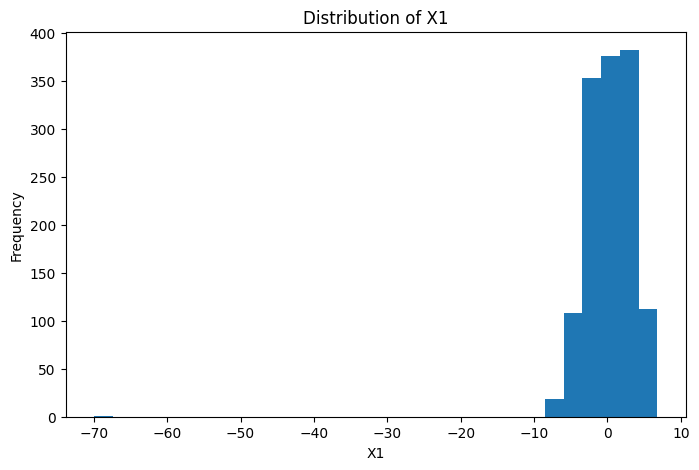

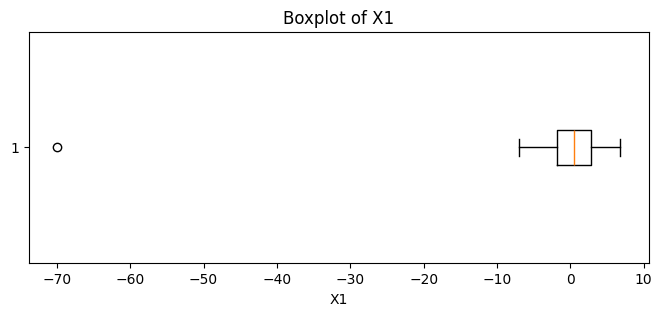

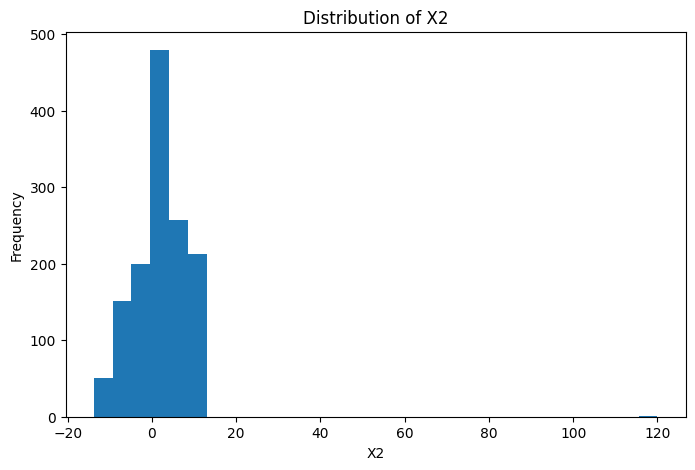

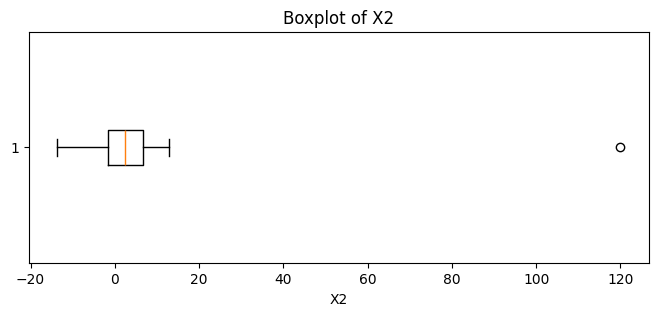

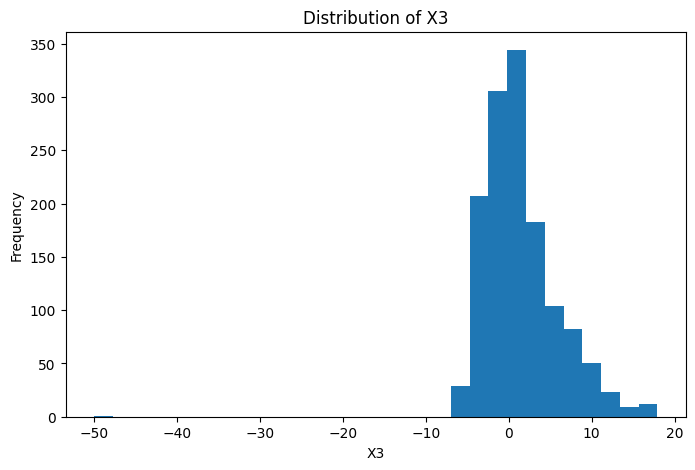

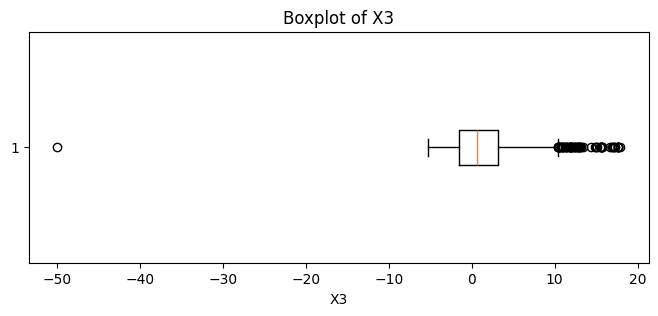

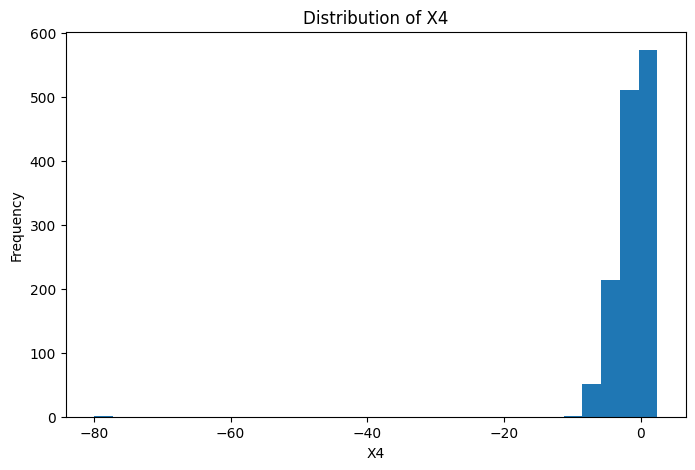

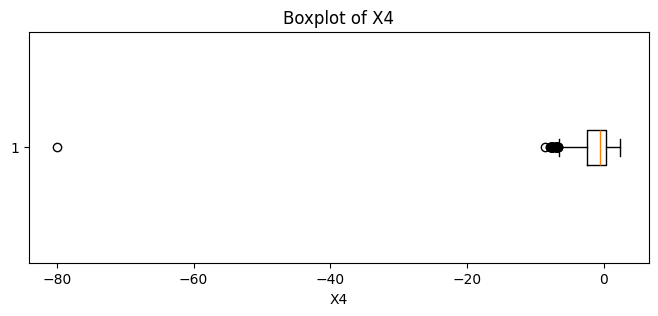

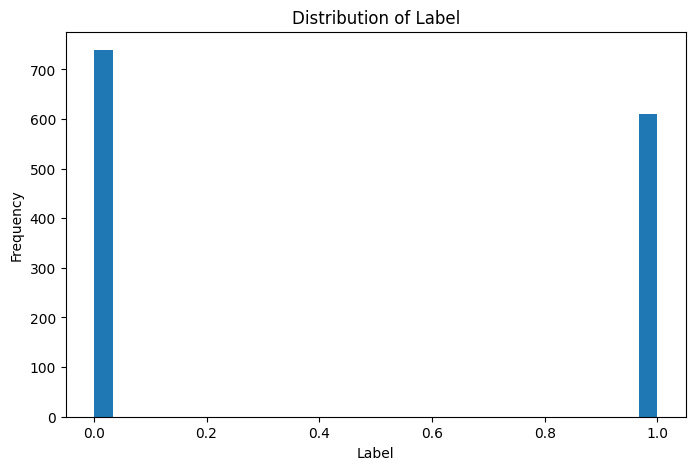

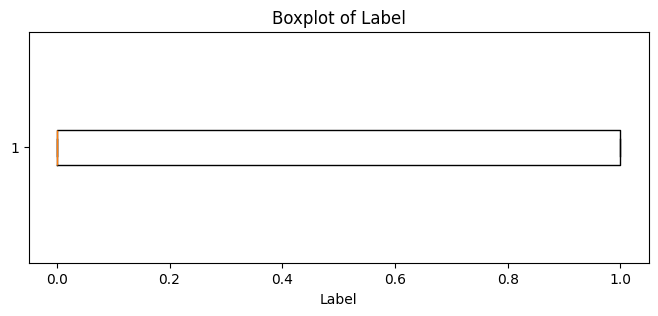

In [ ]:
numeric_cols_df1 = df1_clean.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns in Dataset 1:", numeric_cols_df1)

for col in numeric_cols_df1:
    plot_distribution(df1_clean, col)


## 1.8 EDA: Correlation Matrix

The correlation matrix helps identify relationships among numeric features.

,X1,X2,X3,X4,Label
X1,1.000000,-0.068832,-0.134397,0.557940,-0.596750
X2,-0.068832,1.000000,-0.803053,-0.662660,-0.406245
X3,-0.134397,-0.803053,1.000000,0.427258,0.154453
X4,0.557940,-0.662660,0.427258,1.000000,-0.005920
Label,-0.596750,-0.406245,0.154453,-0.005920,1.000000


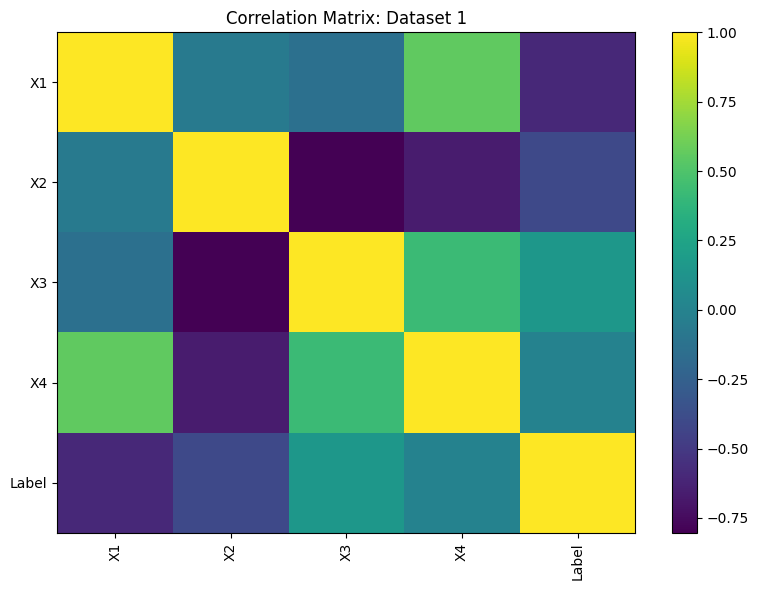

In [ ]:
if len(numeric_cols_df1) >= 2:
    corr_df1 = df1_clean[numeric_cols_df1].corr()
    display(corr_df1)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr_df1, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr_df1.columns)), corr_df1.columns, rotation=90)
    plt.yticks(range(len(corr_df1.index)), corr_df1.index)
    plt.title("Correlation Matrix: Dataset 1")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")


## 1.9 Required Comparison: X1 and X4

This section directly answers the brief requirement to uncover at least one key difference between the distributions of **X1** and **X4**.

Use the automatic key-difference statement and the summary table in the written report.

,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness,kurtosis
X1,1350.0,0.394255,3.443941,-70.0,-1.78795,0.518735,2.852250,6.8248,0.518735,4.640200,-6.399683,128.023432
X4,1350.0,-1.226546,2.991347,-80.0,-2.39310,-0.578890,0.402247,2.4495,-0.578890,2.795348,-13.873377,355.869696


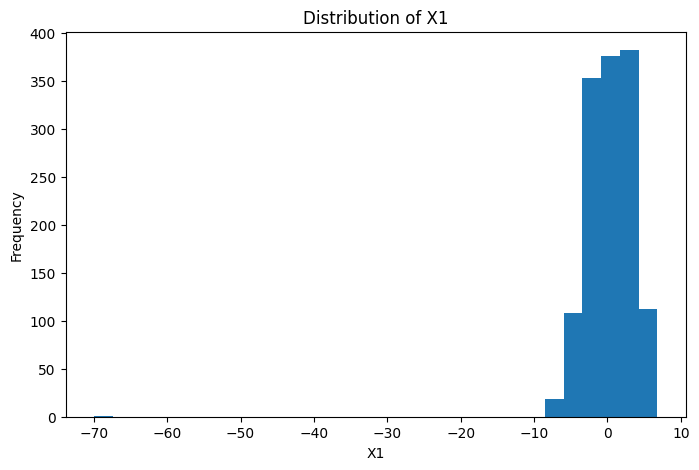

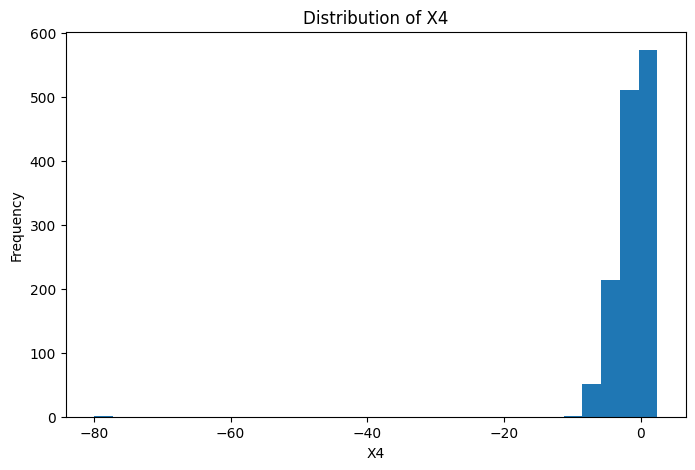

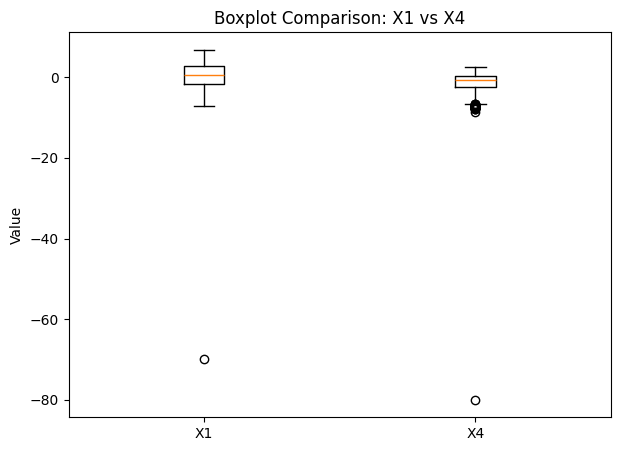


Automatic key-difference statement for report:
- X1 has the higher average value.
- X1 has greater standard deviation, meaning its values are more widely spread.
- X1 has a larger IQR, meaning its middle 50% of values are more dispersed.
- X4 shows stronger skewness, meaning its distribution is less symmetrical.


In [ ]:
compare_two_numeric_features(df1_clean, "X1", "X4")


# Task 2: Class Probability, Gini Impurity, Entropy and Misclassification Rate

Task 2 uses the clean Dataset 1 and the **Label** column. The class probabilities are based on the number of 0s and 1s in the Label column.

## 2.1 Clean and Validate the Label Column

This cell ensures the **Label** column is in a valid binary format before probability calculations. Rows with missing or invalid Label values are removed for Task 2 only.

In [ ]:
label_col = "Label"

if label_col not in df1_clean.columns:
    raise ValueError("The required 'Label' column is missing. Please check Dataset 1 column names.")

df1_task2 = df1_clean.copy()
df1_task2[label_col] = pd.to_numeric(df1_task2[label_col], errors="coerce")

before_label_clean = len(df1_task2)
df1_task2 = df1_task2[df1_task2[label_col].isin([0, 1])].copy()
after_label_clean = len(df1_task2)

print(f"Rows removed due to missing or invalid Label values: {before_label_clean - after_label_clean}")
print("Task 2 dataset shape:", df1_task2.shape)

label_counts = df1_task2[label_col].value_counts().sort_index()
label_probs = df1_task2[label_col].value_counts(normalize=True).sort_index()

print("\nClass counts:")
display(label_counts)

print("\nClass probabilities:")
display(label_probs)

p0 = float(label_probs.get(0, 0))
p1 = float(label_probs.get(1, 0))

print(f"p0 = {p0:.6f}")
print(f"p1 = {p1:.6f}")


Rows removed due to missing or invalid Label values: 1
Task 2 dataset shape: (1349, 5)

Class counts:


,count
Label,
0.0,739
1.0,610



Class probabilities:


,proportion
Label,
0.0,0.547813
1.0,0.452187


p0 = 0.547813
p1 = 0.452187


## 2.2 Gini Impurity

\[
Gini = 1 - (p_0^2 + p_1^2)
\]


In [ ]:
gini_impurity = 1 - (p0**2 + p1**2)
print(f"Gini impurity = {gini_impurity:.6f}")


Gini impurity = 0.495428


## 2.3 Entropy

\[
Entropy = -(p_0 \log_2(p_0) + p_1 \log_2(p_1))
\]


In [ ]:
def safe_entropy(*probs):
    return -sum(p * math.log2(p) for p in probs if p > 0)

entropy_value = safe_entropy(p0, p1)
print(f"Entropy = {entropy_value:.6f}")


Entropy = 0.993394


## 2.4 Misclassification Rate

The safest baseline interpretation is the error from always predicting the majority class:

\[
Misclassification\ Rate = \min(p_0, p_1)
\]

This is proportional to the false positive plus false negative outcomes because all observations from the minority class are misclassified by the majority-class baseline.

For transparency, the random probability-based expected misclassification rate is also shown:

\[
Random\ Expected\ Error = 2p_0p_1
\]


In [ ]:
majority_class = 0 if p0 >= p1 else 1
minority_class = 1 - majority_class

majority_baseline_error = min(p0, p1)
random_probability_error = 2 * p0 * p1

n0 = int(label_counts.get(0, 0))
n1 = int(label_counts.get(1, 0))

if majority_class == 0:
    false_positives = 0
    false_negatives = n1
else:
    false_positives = n0
    false_negatives = 0

total = n0 + n1
fp_fn_rate = (false_positives + false_negatives) / total if total > 0 else np.nan

task2_results = pd.DataFrame({
    "Measure": [
        "Number of class 0",
        "Number of class 1",
        "Probability of class 0",
        "Probability of class 1",
        "Gini impurity",
        "Entropy",
        "Majority predicted class",
        "False positives under majority-class baseline",
        "False negatives under majority-class baseline",
        "Misclassification rate based on FP + FN",
        "Random probability-based expected error"
    ],
    "Value": [
        n0,
        n1,
        p0,
        p1,
        gini_impurity,
        entropy_value,
        majority_class,
        false_positives,
        false_negatives,
        fp_fn_rate,
        random_probability_error
    ]
})

display(task2_results)


,Measure,Value
0,Number of class 0,739.000000
1,Number of class 1,610.000000
2,Probability of class 0,0.547813
3,Probability of class 1,0.452187
4,Gini impurity,0.495428
5,Entropy,0.993394
6,Majority predicted class,0.000000
7,False positives under majority-class baseline,0.000000
8,False negatives under majority-class baseline,610.000000
9,Misclassification rate based on FP + FN,0.452187


# Task 3: Regression Modelling and Trend Analysis

Task 3 requires Dataset 2 to be loaded, a suitable regression model to be selected, trained and evaluated, and underlying trends in the data to be identified.

## 3.1 Load Dataset 2

Dataset 2 link from the brief:

`https://drive.google.com/file/d/1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn/view?usp=sharing`


In [ ]:
dataset2_file_id = "1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn"
dataset2_path = "dataset2_downloaded_file"

download_google_drive_file(dataset2_file_id, dataset2_path)
df2_raw = load_dataset(dataset2_path)

print("Dataset 2 loaded.")
print("Shape:", df2_raw.shape)
display(df2_raw.head())


Downloading...
From: https://drive.google.com/uc?id=1wJj-Cy5f5KmVEmD8KQH6ncup2JHNGSxn
To: /content/dataset2_downloaded_file
100%|██████████| 34.5k/34.5k [00:00<00:00, 47.0MB/s]

Downloaded successfully: dataset2_downloaded_file
Dataset 2 loaded.
Shape: (1000, 2)


,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910


### Manual upload backup for Dataset 2

Run this cell only if automatic Google Drive download fails.

In [ ]:
# from google.colab import files
# uploaded = files.upload()
# dataset2_path = list(uploaded.keys())[0]
# df2_raw = load_dataset(dataset2_path)
# print("Dataset 2 manually uploaded.")
# print("Shape:", df2_raw.shape)
# display(df2_raw.head())


## 3.2 Inspect and Clean Dataset 2

In [ ]:
print("Rows and columns:", df2_raw.shape)

print("\nColumn names:")
print(df2_raw.columns.tolist())

print("\nData types:")
display(df2_raw.dtypes)

print("\nDuplicate rows:", df2_raw.duplicated().sum())

print("\nQuality report before cleaning:")
display(data_quality_report(df2_raw))

print("\nPossible outliers before cleaning:")
display(outlier_report_iqr(df2_raw.select_dtypes(include=np.number)))

df2_clean, converted_cols_df2 = clean_dataset_basic(df2_raw)

print("\nCleaned Dataset 2 shape:", df2_clean.shape)
display(df2_clean.head())

print("\nQuality report after cleaning:")
display(data_quality_report(df2_clean))

print("\nDeficiency and cleaning action summary:")
display(deficiency_action_summary(df2_raw, df2_clean, converted_cols=converted_cols_df2))


Rows and columns: (1000, 2)

Column names:
['t', 'f(t)']

Data types:


,0
t,float64
f(t),float64



Duplicate rows: 0

Quality report before cleaning:


,column,dtype,missing_count,missing_percent,unique_values
0,t,float64,0,0.0,1000
1,f(t),float64,0,0.0,1000



Possible outliers before cleaning:


...

,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910



Quality report after cleaning:


,column,dtype,missing_count,missing_percent,unique_values
0,t,float64,0,0.0,1000
1,f(t),float64,0,0.0,1000



Deficiency and cleaning action summary:


,deficiency,evidence,action_taken
0,No major structural deficiency found,No duplicates or major missing-value issues de...,Dataset retained after basic standardisation


## 3.3 Select the Regression Target

A regression target should be a continuous numeric variable. The code attempts to identify the target automatically using common target names. If the selected target is not correct, manually override `target_col` in the marked line.

In [ ]:
possible_targets = [
    "target", "Target", "TARGET",
    "y", "Y",
    "output", "Output",
    "value", "Value",
    "price", "Price",
    "sales", "Sales",
    "demand", "Demand",
    "score", "Score"
]

target_col = None

for col in possible_targets:
    if col in df2_clean.columns and pd.api.types.is_numeric_dtype(df2_clean[col]):
        target_col = col
        break

if target_col is None:
    numeric_cols = df2_clean.select_dtypes(include=np.number).columns.tolist()
    if not numeric_cols:
        raise ValueError("No numeric column is available for regression.")
    target_col = numeric_cols[-1]

print("Automatically selected target column:", target_col)
print("\nNumeric columns available:")
print(df2_clean.select_dtypes(include=np.number).columns.tolist())

# IMPORTANT MANUAL OVERRIDE:
# If the selected target is incorrect after checking the dataset, uncomment and edit this line:
# target_col = "your_actual_target_column_name"


Automatically selected target column: f(t)

Numeric columns available:
['t', 'f(t)']


## 3.4 Underlying Trend Analysis Before Modelling

This section checks:

- Correlation between numeric features and the target.
- Scatter plots for the strongest relationships.
- Time/date trend if a date-like column is available.

These outputs help explain the underlying trends in the dataset.

,correlation_with_target
f(t),1.000000
t,-0.750757


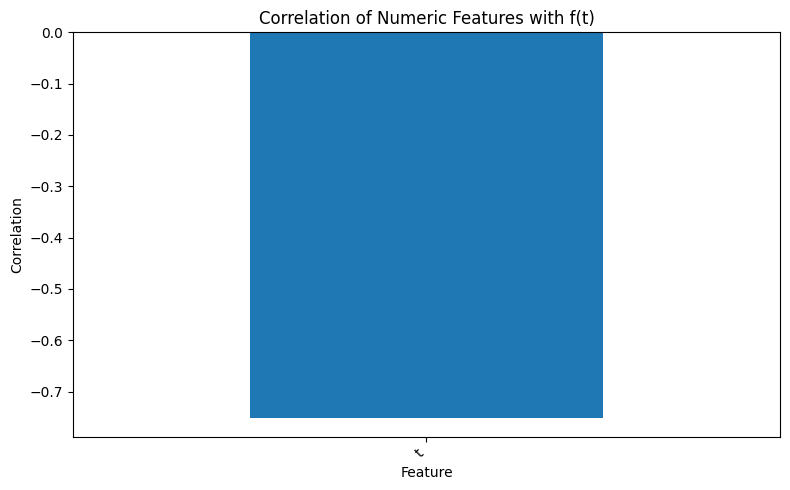

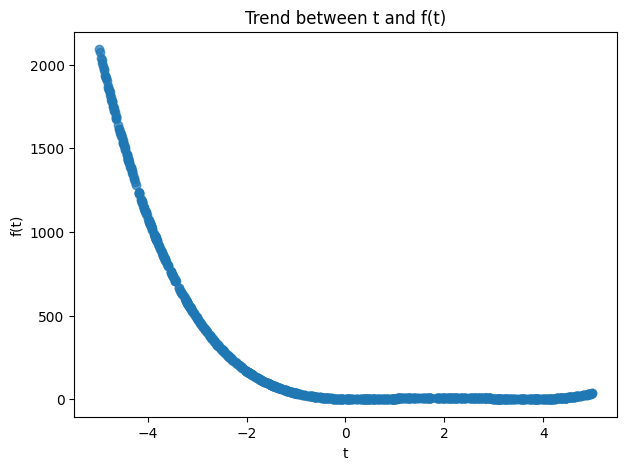

In [ ]:
df2_trend = df2_clean.copy()

# Correlation trend analysis
numeric_cols_df2 = df2_trend.select_dtypes(include=np.number).columns.tolist()

if target_col in numeric_cols_df2 and len(numeric_cols_df2) > 1:
    corr_with_target = df2_trend[numeric_cols_df2].corr()[target_col].sort_values(ascending=False)
    display(corr_with_target.to_frame("correlation_with_target"))

    plt.figure(figsize=(8, 5))
    corr_with_target.drop(target_col, errors="ignore").plot(kind="bar")
    plt.title(f"Correlation of Numeric Features with {target_col}")
    plt.ylabel("Correlation")
    plt.xlabel("Feature")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    top_corr_features = corr_with_target.drop(target_col, errors="ignore").abs().sort_values(ascending=False).head(3).index.tolist()

    for feature in top_corr_features:
        plt.figure(figsize=(7, 5))
        plt.scatter(df2_trend[feature], df2_trend[target_col], alpha=0.7)
        plt.title(f"Trend between {feature} and {target_col}")
        plt.xlabel(feature)
        plt.ylabel(target_col)
        plt.show()
else:
    print("Correlation trend analysis requires at least two numeric columns including the target.")


In [ ]:
# Optional date/time trend detection
date_like_cols = []

for col in df2_trend.columns:
    if col == target_col:
        continue
    if df2_trend[col].dtype == "object":
        converted_date = pd.to_datetime(df2_trend[col], errors="coerce")
        if converted_date.notna().mean() >= 0.70:
            date_like_cols.append(col)

print("Date-like columns detected:", date_like_cols)

if date_like_cols:
    date_col = date_like_cols[0]
    temp = df2_trend[[date_col, target_col]].copy()
    temp[date_col] = pd.to_datetime(temp[date_col], errors="coerce")
    temp = temp.dropna().sort_values(date_col)

    plt.figure(figsize=(9, 5))
    plt.plot(temp[date_col], temp[target_col])
    plt.title(f"Time Trend of {target_col} by {date_col}")
    plt.xlabel(date_col)
    plt.ylabel(target_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No clear date-like column detected. Trends are interpreted through correlations and feature relationships.")


Date-like columns detected: []
No clear date-like column detected. Trends are interpreted through correlations and feature relationships.


## 3.5 Prepare Data for Regression

This section separates features and target, removes rows with missing target values, and builds preprocessing pipelines for numeric and categorical variables.

In [ ]:
df2_model = df2_clean.dropna(subset=[target_col]).copy()

X = df2_model.drop(columns=[target_col])
y = df2_model[target_col]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Target variable:", target_col)
print("Number of rows used for modelling:", len(df2_model))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

transformers = []
if numeric_features:
    transformers.append(("num", numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)


Target variable: f(t)
Number of rows used for modelling: 1000
Numeric features: ['t']
Categorical features: []
Training feature shape: (800, 1)
Testing feature shape: (200, 1)


## 3.6 Model Choice and Justification

Several regression models are tested because the dataset structure may contain either linear or non-linear relationships:

- **Linear Regression:** simple baseline model.
- **Ridge Regression:** regularised linear model to reduce overfitting risk.
- **Random Forest Regressor:** captures non-linear patterns and feature interactions.
- **Gradient Boosting Regressor:** captures complex predictive patterns through sequential tree boosting.

The most appropriate final model is selected using test-set performance, mainly **RMSE** and **R²**.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=250, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by=["RMSE", "MAE"], ascending=True)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

print(f"Selected best model based on lowest RMSE: {best_model_name}")


,Model,MAE,RMSE,R2
2,Random Forest Regressor,1.093184,3.688983,0.999947
3,Gradient Boosting Regressor,1.990023,4.089672,0.999935
0,Linear Regression,259.549289,330.917916,0.575021
1,Ridge Regression,259.431004,330.927910,0.574995


Selected best model based on lowest RMSE: Random Forest Regressor


## 3.7 Cross-Validation Check

Cross-validation provides a more stable estimate of model performance. This strengthens the model evaluation beyond a single train-test split.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    neg_rmse_scores = cross_val_score(
        pipeline, X, y, cv=cv, scoring="neg_root_mean_squared_error"
    )
    r2_scores = cross_val_score(
        pipeline, X, y, cv=cv, scoring="r2"
    )

    cv_results.append({
        "Model": model_name,
        "CV_RMSE_Mean": -neg_rmse_scores.mean(),
        "CV_RMSE_Std": neg_rmse_scores.std(),
        "CV_R2_Mean": r2_scores.mean(),
        "CV_R2_Std": r2_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE_Mean")
display(cv_results_df)


,Model,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std
2,Random Forest Regressor,2.562010,0.769382,0.999971,0.000014
3,Gradient Boosting Regressor,3.691458,0.754485,0.999942,0.000016
1,Ridge Regression,324.216223,14.842316,0.558032,0.018204
0,Linear Regression,324.217126,14.818391,0.558023,0.018281


## 3.8 Predicted vs Actual Values

This plot evaluates how close the selected model's predictions are to the actual target values.

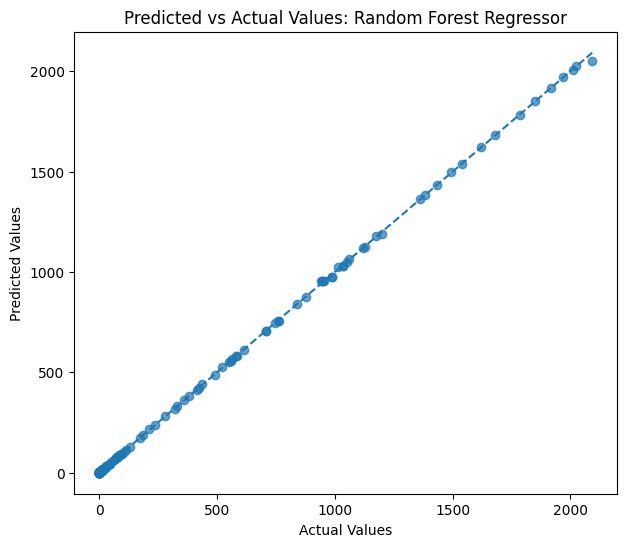

,Actual,Predicted,Residual
0,11.597726,11.693083,-0.095357
1,747.932428,746.371774,1.560654
2,13.846130,13.739695,0.106435
3,3.444835,3.434699,0.010135
4,1.926836,1.924415,0.002421
5,31.077397,31.730119,-0.652722
6,6.550870,6.430047,0.120824
7,1678.575576,1682.541429,-3.965853
8,213.435783,215.722676,-2.286893
9,3.491671,3.475702,0.015969


In [ ]:
y_pred_best = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Predicted vs Actual Values: {best_model_name}")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

prediction_table = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best,
    "Residual": y_test.values - y_pred_best
})

display(prediction_table.head(20))


## 3.9 Residual Analysis

Residual plots help assess whether model errors are randomly distributed or whether the model is missing a systematic pattern.

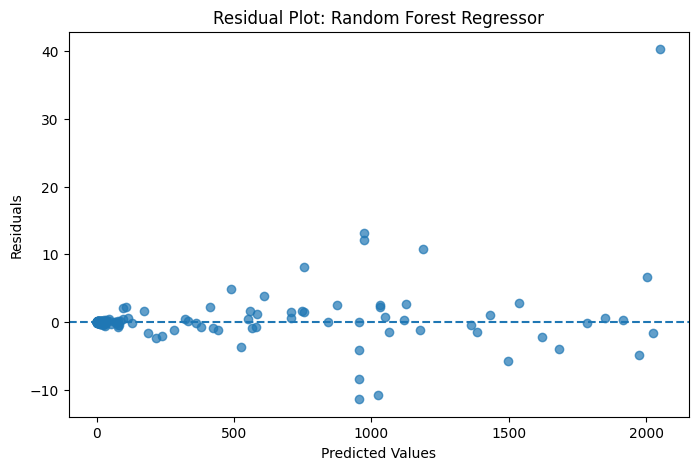

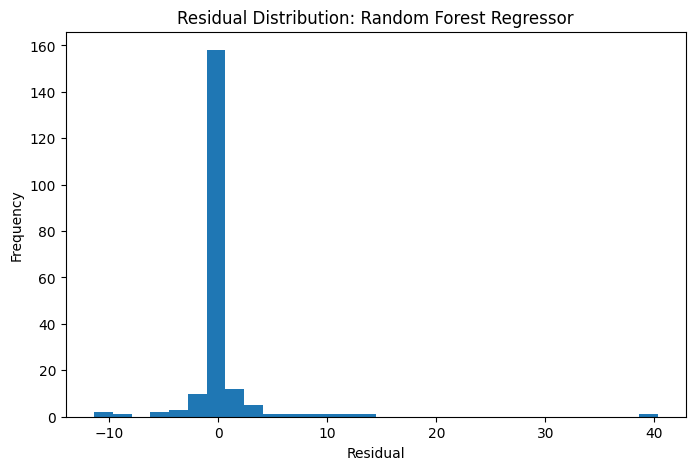

Final selected model performance:
MAE: 1.093184
RMSE: 3.688983
R2: 0.999947


In [ ]:
residuals = y_test.values - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot: {best_model_name}")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title(f"Residual Distribution: {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

final_metrics = regression_metrics(y_test, y_pred_best)
print("Final selected model performance:")
for k, v in final_metrics.items():
    print(f"{k}: {v:.6f}")


## 3.10 Feature Importance / Coefficient Interpretation

This section identifies the main predictors behind the regression model. For tree-based models, feature importance is reported. For linear models, coefficients are reported.

,Feature,Importance
0,t,1.0


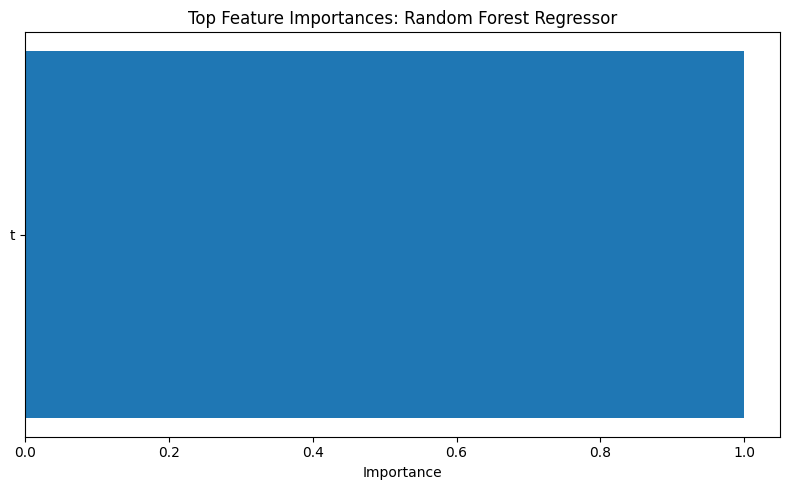

In [ ]:
def get_feature_names_from_preprocessor(preprocessor):
    names = []

    for transformer_name, transformer, columns in preprocessor.transformers_:
        if transformer_name == "remainder":
            continue

        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, "get_feature_names_out"):
                transformed_names = last_step.get_feature_names_out(columns)
                names.extend(transformed_names)
            else:
                names.extend(columns)
        else:
            names.extend(columns)

    return list(names)


fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model = best_pipeline.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)

if hasattr(fitted_model, "feature_importances_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": fitted_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(interpretation_df.head(20))

    top_items = interpretation_df.head(10).sort_values("Importance")
    plt.figure(figsize=(8, 5))
    plt.barh(top_items["Feature"], top_items["Importance"])
    plt.title(f"Top Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

elif hasattr(fitted_model, "coef_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": fitted_model.coef_
    })
    interpretation_df["Absolute_Coefficient"] = interpretation_df["Coefficient"].abs()
    interpretation_df = interpretation_df.sort_values(by="Absolute_Coefficient", ascending=False)

    display(interpretation_df.head(20))

    top_items = interpretation_df.head(10).sort_values("Absolute_Coefficient")
    plt.figure(figsize=(8, 5))
    plt.barh(top_items["Feature"], top_items["Coefficient"])
    plt.title(f"Top Regression Coefficients: {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

else:
    print("The selected model does not expose direct feature importance or coefficients.")
